# L5.1 — Tokenization & BPE

Hands-on notebook for the lesson [`5-1-tokenization.mdx`](../../llm-quest-theory/level-5/5-1-tokenization.mdx).

> **Learning objectives**
> - Train a byte-pair encoding tokenizer from scratch on a tiny corpus with `tokenizers`.
> - Compare the from-scratch tokenizer, GPT-2's tokenizer, and (if available) LLaMA's tokenizer on the same sentence.
> - Reproduce the famous "strawberry" tokenization quirk.
> - Measure how the same prompt costs **more tokens** in some languages than others.

## Connection to the theory
Covers **§1–§8** of the source `.mdx`. Every LLM pipeline starts here — and the decisions made here drive cost, context budget, and multilingual fairness.

In [1]:
# ---- Setup ----
import os
import matplotlib.pyplot as plt

SEED = 42
os.environ["TOKENIZERS_PARALLELISM"] = "false"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

import tokenizers as _tok
import transformers as _hf
print("tokenizers:", _tok.__version__, "  transformers:", _hf.__version__)

tokenizers: 0.20.3   transformers: 4.46.3


## 1. Train a tiny BPE tokenizer from scratch
We give it a small, deliberately repetitive corpus so the merges are easy to interpret.

In [2]:
CORPUS = [
    "low low low low low",
    "lower lower",
    "newest newest newest newest newest newest",
    "widest widest widest",
    "slow slowly slower slowest",
    "tokenization is the first step of every large language model",
    "the quick brown fox jumps over the lazy dog",
] * 5   # repeat to make frequencies meaningful

tok = Tokenizer(BPE(unk_token="[UNK]"))
tok.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=200, special_tokens=["[UNK]"], min_frequency=1)
tok.train_from_iterator(CORPUS, trainer=trainer)
print("learned vocab size:", tok.get_vocab_size())




learned vocab size: 98


## 2. What does it do to familiar vs unfamiliar words?
Common words (seen during training) collapse to one token. Unseen words fall back to multiple pieces.

In [3]:
def show(enc_tokens):
    for s, t in enc_tokens:
        print(f"  {s!r}\n    -> {t}")

examples = [
    "low newest",               # seen
    "slower widestly",          # partially seen
    "tokenizer",                # contains 'token'
    "pytorch",                  # unseen
    "cryptographically",         # very unseen
]
show([(s, tok.encode(s).tokens) for s in examples])

  'low newest'
    -> ['low', 'newest']
  'slower widestly'
    -> ['slower', 'widest', 'ly']
  'tokenizer'
    -> ['token', 'iz', 'er']
  'pytorch'
    -> ['p', 'y', 't', 'o', 'r', 'c', 'h']
  'cryptographically'
    -> ['c', 'r', 'y', 'p', 't', 'o', 'g', 'r', 'a', 'p', 'h', 'i', 'c', 'a', 'l', 'ly']


Observation: unseen words get chopped into whatever pieces do exist in the vocabulary. That is exactly how BPE handles "out-of-vocabulary" in production.

## 3. Peek at the learned merges
BPE records the order in which pairs were glued together.

In [4]:
# Save the trained tokenizer to inspect its merges.json-style contents
tok.save("/tmp/bpe_tiny.json")
import json
data = json.load(open("/tmp/bpe_tiny.json"))
merges = data["model"]["merges"][:12]
print("First 12 learned merges:")
for m in merges:
    # Depending on tokenizers version, merges are strings or pairs
    if isinstance(m, list):
        a, b = m
    else:
        a, b = m.split()
    print(f"  {a!r:>8}  +  {b!r:>8}   ->  {(a+b)!r}")

First 12 learned merges:
       'o'  +       'w'   ->  'ow'
       's'  +       't'   ->  'st'
       'l'  +      'ow'   ->  'low'
       'e'  +      'st'   ->  'est'
       'e'  +       'w'   ->  'ew'
       'n'  +      'ew'   ->  'new'
     'new'  +     'est'   ->  'newest'
       'e'  +       'r'   ->  'er'
       's'  +     'low'   ->  'slow'
       'd'  +     'est'   ->  'dest'
       'h'  +       'e'   ->  'he'
       'i'  +    'dest'   ->  'idest'


Read these as a trace of BPE's greedy "merge the most frequent pair" loop — exactly the worked example from the theory.

## 4. GPT-2 vs our tiny tokenizer
Load the pretrained GPT-2 tokenizer (small download the first time). It uses **byte-level BPE** with a 50 257-token vocabulary.

In [5]:
from transformers import AutoTokenizer
gpt2 = AutoTokenizer.from_pretrained("gpt2")
print("GPT-2 vocab size:", gpt2.vocab_size)

sentence = "Tokenization is the first step of every large language model."
print(f"\nsentence: {sentence!r}")
print("\nOurs   :", tok.encode(sentence).tokens)
print("\nGPT-2  :", gpt2.tokenize(sentence))

GPT-2 vocab size: 50257

sentence: 'Tokenization is the first step of every large language model.'

Ours   : ['[UNK]', 'oken', 'izatio', 'n', 'is', 'the', 'first', 'step', 'of', 'every', 'large', 'language', 'model', '[UNK]']

GPT-2  : ['Token', 'ization', 'Ġis', 'Ġthe', 'Ġfirst', 'Ġstep', 'Ġof', 'Ġevery', 'Ġlarge', 'Ġlanguage', 'Ġmodel', '.']


GPT-2's tokenizer uses the `Ġ` symbol to mean "preceded by a space" — that is a byte-level encoding trick, not a data corruption.

## 5. The "strawberry" quirk
`strawberry` looks like a single word to us. To GPT-2 it is `["str", "aw", "berry"]` — which helps explain why LLMs famously miscount letters inside tokens.

In [6]:
quirky = ["strawberry", "StrawberryCake", "12345", "99999", "mathematical", "Anthropic"]
for w in quirky:
    print(f"  {w!r:<18} -> GPT-2 {gpt2.tokenize(w)}")

  'strawberry'       -> GPT-2 ['st', 'raw', 'berry']
  'StrawberryCake'   -> GPT-2 ['St', 'raw', 'berry', 'C', 'ake']
  '12345'            -> GPT-2 ['123', '45']
  '99999'            -> GPT-2 ['99', '999']
  'mathematical'     -> GPT-2 ['mat', 'hemat', 'ical']
  'Anthropic'        -> GPT-2 ['An', 'throp', 'ic']


Notice how numbers get cut in arbitrary places — that is one reason vanilla GPT-2 is weak at arithmetic.

## 6. Multilingual token inequality
Encode the same sentence in several languages with GPT-2 and count tokens. English gets the fewest; other languages often pay more tokens for the same meaning — which means higher API cost and shorter effective context.

  English                          15 GPT-2 tokens
  French                           34 GPT-2 tokens
  Spanish                          21 GPT-2 tokens
  German                           28 GPT-2 tokens
  Vietnamese (no diacritics)       28 GPT-2 tokens


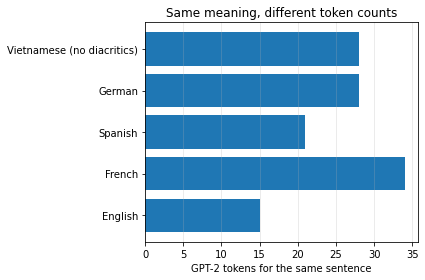

In [7]:
sentences = {
    "English": "Hello, how are you today? I hope you have a great day.",
    "French" : "Bonjour, comment allez-vous aujourd'hui ? J'espere que vous passez une bonne journee.",
    "Spanish": "Hola, como estas hoy? Espero que tengas un gran dia.",
    "German" : "Hallo, wie geht es Ihnen heute? Ich hoffe, Sie haben einen tollen Tag.",
    "Vietnamese (no diacritics)": "Xin chao, hom nay ban khoe khong? Hy vong ban co mot ngay tuyet voi.",
}
counts = {k: len(gpt2.encode(v)) for k, v in sentences.items()}
for k, c in counts.items():
    print(f"  {k:<30}  {c:>3} GPT-2 tokens")

fig, ax = plt.subplots()
ax.barh(list(counts.keys()), list(counts.values()))
ax.set_xlabel("GPT-2 tokens for the same sentence")
ax.set_title("Same meaning, different token counts"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 7. Byte-level BPE never blows up on rare characters
Byte-level BPE starts from 256 byte values — emoji, Unicode, anything. Even a cow emoji tokenizes.

In [8]:
weird = ["hello 🦙", "good morning ☀️", "naïve café", "∑(x_i)", "こんにちは"]
for w in weird:
    ids = gpt2.encode(w)
    print(f"  {w!r:<20} -> {len(ids)} tokens")

  'hello 🦙'            -> 4 tokens
  'good morning ☀️'    -> 5 tokens
  'naïve café'         -> 3 tokens
  '∑(x_i)'             -> 7 tokens
  'こんにちは'              -> 6 tokens


## 8. Quick checks

In [9]:
# Our trained tokenizer must reach the requested vocab size (up to trainer rounding)
assert tok.get_vocab_size() >= 50, "tiny BPE must learn a non-trivial vocab"
# Common seen word collapses to one token; unseen word is multi-piece
assert len(tok.encode("low").tokens)        == 1
assert len(tok.encode("cryptographically").tokens) > 3
# GPT-2 sees 'strawberry' as multiple pieces
assert len(gpt2.tokenize("strawberry")) >= 2
# Non-English sentences should cost more tokens than the English one (on average for this set)
en = counts["English"]
others_avg = sum(v for k, v in counts.items() if k != "English") / (len(counts) - 1)
assert others_avg > en, "non-English sentences should cost more GPT-2 tokens on average"
# Byte-level BPE never fails
for w in weird:
    assert len(gpt2.encode(w)) > 0
print("OK — BPE behaves, cross-language cost difference is real, byte-level never breaks.")

OK — BPE behaves, cross-language cost difference is real, byte-level never breaks.


## Reflection questions

1. Our tiny tokenizer has vocab ≈ 200 and encodes `cryptographically` as many pieces. GPT-2 has vocab 50 257 and needs how many? Why is the gap so stark for a long, rare word?
2. Section 6 shows Vietnamese-without-diacritics still costs more tokens than English. What happens with the real diacritics `à, ê, ơ, ử`?
3. Given the "strawberry" tokenization, why is GPT-style `chat` still good at spelling tasks despite not seeing individual letters for most words?
4. Can you extend a pre-trained tokenizer with new tokens? What has to change in the model itself? (Hint: the embedding table.)

## References
- Source theory: [`5-1-tokenization.mdx`](../../llm-quest-theory/level-5/5-1-tokenization.mdx)
- Next: [`5-2-embedding`](5-2-embedding.ipynb)